# Master in Applied Artificial Intelligence

## Course: *Computer Vision for Images and Video*

### **6.4 Google Colab** - Feature Extraction Algorithms

---

**Institution:** Tecnológico de Monterrey

**Instructors:** Gilberto Ochoa Ruiz, Daniel Flores Araiza, Ma. del Refugio Meléndez Alfaro

**Authors (Team 38):** 

|  FULL NAME                      |     STUDENT ID    | 
| :--------------------------:    |:-----------------:|
| Alejandro Díaz Villagómez       |  A01276769        | 
| Carlos Rodrigo Sánchez Sierra   |  A01424454        | 
| Emiliano Saucedo Arriola        |  A01659258        | 

**Date:** October 26th, 2025

---

# 7.1. Harris Edge & Corner Detection

## Table of Contents
1. [Libraries](#libraries)
2. [Color image to Grayscale conversion](#grayscale)
3. [Spatial derivative calculation](#spatial)
4. [Structure tensor setup](#tensor)
5. [Harris response calculation](#response)
6. [Find edges and corners using R](#find)

## Importing Libraries <a class="anchor" id="libraries" ></a>

In [1]:
import cv2
import matplotlib.pyplot as plt
from scipy import signal as sig
import numpy as np
from scipy.ndimage import convolve
import os

## 1. Color to Grayscale <a class="anchor" id="grayscale" ></a>

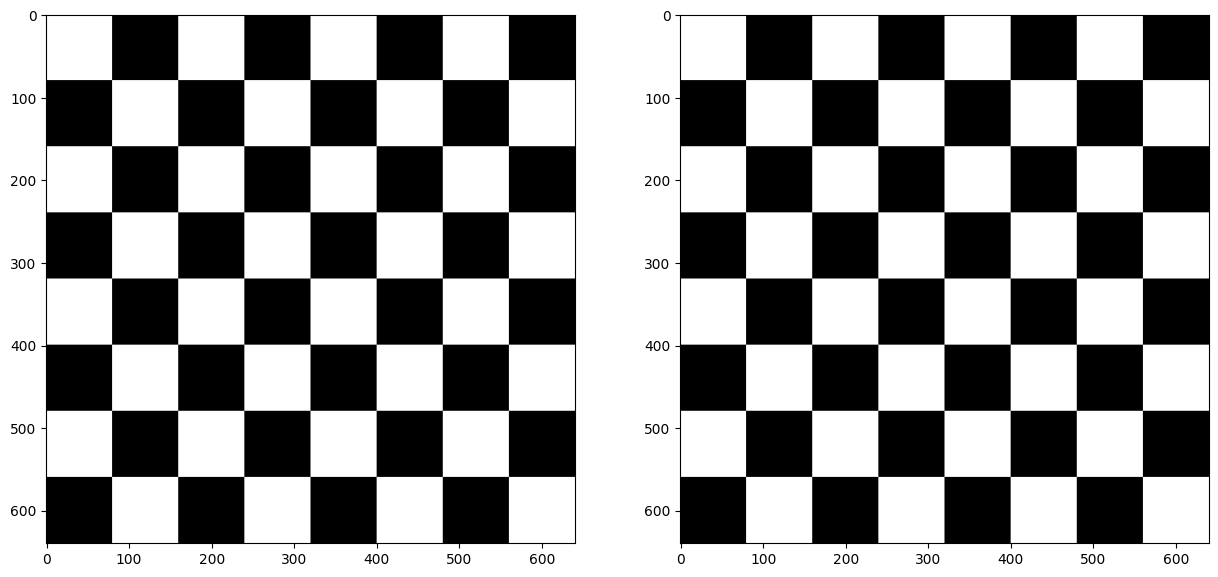

In [2]:
img = cv2.imread('data/chessboard.jpg')
img_color = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)
plt.imshow(img_color)
plt.subplot(1, 2, 2)
plt.imshow(img_gray, cmap="gray")

## 2. Spatial derivative calculation <a class="anchor" id="spatial" ></a>

In [3]:
def gradient_x(imggray):
    ##Sobel operator kernels.
    kernel_x = np.array([[-1, 0, 1],[-2, 0, 2],[-1, 0, 1]])
    return sig.convolve2d(imggray, kernel_x, mode='same')

def gradient_y(imggray):
    kernel_y = np.array([[1, 2, 1], [0, 0, 0], [-1, -2, -1]])
    return sig.convolve2d(imggray, kernel_y, mode='same')

I_x = gradient_x(img_gray)
I_y = gradient_y(img_gray)

## 3. Structure tensor setup <a class="anchor" id="tensor" ></a>

In [4]:
def gaussian_kernel(size, sigma=1):
    size = int(size) // 2
    x, y = np.mgrid[-size:size+1, -size:size+1]
    normal = 1 / (2.0 * np.pi * sigma**2)
    g =  np.exp(-((x**2 + y**2) / (2.0*sigma**2))) * normal
    return g


Ixx = convolve(I_x**2, gaussian_kernel(3, 1))
Ixy = convolve(I_y*I_x, gaussian_kernel(3, 1))
Iyy = convolve(I_y**2, gaussian_kernel(3, 1))

## 4. Harris response calculation <a class="anchor" id="response" ></a>

In [5]:
k = 0.05

# determinant
detA = Ixx * Iyy - Ixy ** 2

# trace
traceA = Ixx + Iyy
    
harris_response = detA - k * traceA ** 2

In [6]:
img_gray.shape

(640, 640)

In [7]:
window_size = 3
offset = window_size//2
width, height = img_gray.shape

for y in range(offset, height-offset):
    for x in range(offset, width-offset):
        Sxx = np.sum(Ixx[y-offset:y+1+offset, x-offset:x+1+offset])
        Syy = np.sum(Iyy[y-offset:y+1+offset, x-offset:x+1+offset])
        Sxy = np.sum(Ixy[y-offset:y+1+offset, x-offset:x+1+offset])

In [8]:
#Find determinant and trace, use to get corner response
det = (Sxx * Syy) - (Sxy**2)
trace = Sxx + Syy
r = det - k*(trace**2)

## 5. Find edges and corners using R <a class="anchor" id="find" ></a>

In [9]:
img_copy_for_corners = np.copy(img)
img_copy_for_edges = np.copy(img)

for rowindex, response in enumerate(harris_response):
    for colindex, r in enumerate(response):
        if r > 0:
            # this is a corner
            img_copy_for_corners[rowindex, colindex] = [255,0,0]
        elif r < 0:
            # this is an edge
            img_copy_for_edges[rowindex, colindex] = [0,255,0]

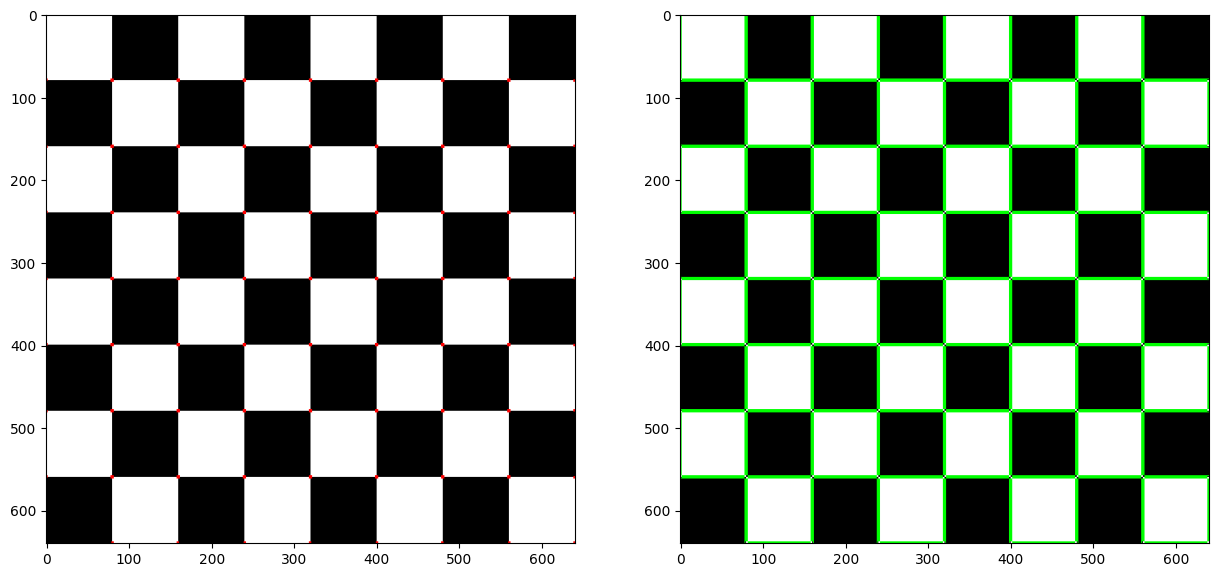

In [10]:
plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)
plt.imshow(img_copy_for_corners, cmap="gray")
plt.subplot(1, 2, 2)
plt.imshow(img_copy_for_edges, cmap="gray")

# > Solution

**Research Background**

* **Introduction to Corner Detection**

    Corner detection represents a fundamental task in computer vision, serving as a crucial preprocessing step for various applications including image matching, object recognition, and motion tracking. Among the various corner detection algorithms developed over the decades, the Harris corner detector stands out as one of the most robust and widely adopted methods (Harris & Stephens, 1988). Unlike edge detectors that identify regions of rapid intensity change in a single direction, corner detectors aim to locate points where intensity changes occur in multiple directions simultaneously—features that provide highly distinctive and stable landmarks for subsequent image analysis tasks (Shi & Tomasi, 1994). The importance of corners lies in their repeatability and distinctiveness: they tend to be consistent across different viewpoints and lighting conditions, making them ideal candidates for tracking and matching operations.

* **Mathematical Framework**

    The Harris corner detector operates by analyzing the local structure of intensity variations within an image. The algorithm begins by computing the gradient of the image intensity in both x and y directions, typically using Sobel operators or similar derivative filters (Szeliski, 2010). These gradients are then used to construct the structure tensor (also known as the second-moment matrix), which captures the distribution of gradient directions in a local neighborhood around each pixel. Mathematically, this structure tensor M is defined as:

    $$M = \sum_{(x,y) \in W} w(x,y) \begin{bmatrix} I_x^2 & I_xI_y \\ I_xI_y & I_y^2 \end{bmatrix}$$

    where $I_x$ and $I_y$ represent the image derivatives, W denotes a local window, and w(x,y) is typically a Gaussian weighting function that emphasizes the center of the window (Harris & Stephens, 1988). The eigenvalues of this matrix reveal the principal directions and magnitudes of intensity variation: large eigenvalues in multiple directions indicate corners, while large values in only one direction suggest edges.

* **The Harris Response Function**

    Rather than explicitly computing eigenvalues (a computationally expensive operation) Harris and Stephens (1988) introduced a corner response function R that provides an efficient approximation: R = det(M) - k·trace(M)², where det(M) represents the determinant, trace(M) is the sum of diagonal elements, and k is an empirically determined constant typically set between 0.04 and 0.06. This response function elegantly captures the relationship between the eigenvalues: when both eigenvalues are large (indicating a corner), R is positive and large; when one eigenvalue is large and the other small (indicating an edge), R is negative; and when both are small (indicating a flat region), R is close to zero (Förstner & Gülch, 1987). The beauty of this formulation lies in its computational efficiency and its invariance to image rotation, making it particularly suitable for real-time applications and scenarios where objects appear at varying orientations.

* **Robustness and Practical Considerations**

    While the Harris detector exhibits remarkable robustness to rotation and moderate illumination changes, its performance can be affected by scale variations, extreme lighting conditions, and perspective distortions (Mikolajczyk & Schmid, 2004). The detector's sensitivity to these factors stems from its reliance on local gradient information, which can be suppressed in low-light conditions or amplified under harsh lighting that creates strong shadows. Additionally, the choice of parameters (particularly the window size for the structure tensor and the threshold for corner response) significantly impacts detection performance and must be carefully tuned for specific applications (Schmid et al., 2000). Understanding these limitations is essential for practitioners seeking to apply the Harris detector effectively across diverse imaging conditions, motivating experimental investigations that systematically evaluate its behavior under controlled variations in illumination, viewpoint, and object characteristics.


**References**

- Förstner, W., & Gülch, E. (1987). A fast operator for detection and precise location of distinct points, corners and centres of circular features. *ISPRS Intercommission Conference on Fast Processing of Photogrammetric Data*, 281-305.

- Harris, C., & Stephens, M. (1988). A combined corner and edge detector. *Alvey Vision Conference*, 15(50), 10-5244.

- Mikolajczyk, K., & Schmid, C. (2004). Scale & affine invariant interest point detectors. *International Journal of Computer Vision*, 60(1), 63-86. https://doi.org/10.1023/B:VISI.0000027790.02288.f2

- Schmid, C., Mohr, R., & Bauckhage, C. (2000). Evaluation of interest point detectors. *International Journal of Computer Vision*, 37(2), 151-172. https://doi.org/10.1023/A:1008199403446

- Shi, J., & Tomasi, C. (1994). Good features to track. *IEEE Conference on Computer Vision and Pattern Recognition*, 593-600. https://doi.org/10.1109/CVPR.1994.323794

- Szeliski, R. (2010). *Computer vision: Algorithms and applications*. Springer Science & Business Media.

In [11]:
def gradient_x(imggray):
    """Calculate horizontal gradient using Sobel operator"""
    kernel_x = np.array([[-1, 0, 1],[-2, 0, 2],[-1, 0, 1]])
    return sig.convolve2d(imggray, kernel_x, mode='same')

def gradient_y(imggray):
    """Calculate vertical gradient using Sobel operator"""
    kernel_y = np.array([[1, 2, 1], [0, 0, 0], [-1, -2, -1]])
    return sig.convolve2d(imggray, kernel_y, mode='same')

In [12]:
def gaussian_kernel(size, sigma=1):
    """Generate Gaussian kernel for smoothing"""
    size = int(size) // 2
    x, y = np.mgrid[-size:size+1, -size:size+1]
    normal = 1 / (2.0 * np.pi * sigma**2)
    g = np.exp(-((x**2 + y**2) / (2.0*sigma**2))) * normal
    return g

In [13]:
def harris_corner_detector(img_gray, k=0.05, threshold_corner=0.01, threshold_edge=-0.01):
    """
    Complete Harris corner detection implementation
    
    Parameters:
    -----------
    img_gray : ndarray
        Grayscale input image
    k : float
        Harris detector free parameter (typically 0.04-0.06)
    threshold_corner : float
        Threshold for corner detection (relative to max response)
    threshold_edge : float
        Threshold for edge detection (relative to min response)
    
    Returns:
    --------
    harris_response : ndarray
        Harris response values for each pixel
    corners : ndarray
        Binary mask of detected corners
    edges : ndarray
        Binary mask of detected edges
    """
    
    # Step 1: Compute image gradients
    I_x = gradient_x(img_gray)
    I_y = gradient_y(img_gray)
    
    # Step 2: Compute products of gradients
    Ixx = convolve(I_x**2, gaussian_kernel(3, 1))
    Ixy = convolve(I_y*I_x, gaussian_kernel(3, 1))
    Iyy = convolve(I_y**2, gaussian_kernel(3, 1))
    
    # Step 3: Compute Harris response
    detA = Ixx * Iyy - Ixy ** 2
    traceA = Ixx + Iyy
    harris_response = detA - k * traceA ** 2
    
    # Step 4: Threshold and classify features
    max_response = harris_response.max()
    min_response = harris_response.min()
    
    corners = harris_response > (threshold_corner * max_response)
    edges = harris_response < (threshold_edge * min_response)
    
    return harris_response, corners, edges

In [14]:
image_paths = [
    'data/harris_detector/keyboard_front.jpg',      # Image 1: Front view, good lighting
    'data/harris_detector/keyboard_side.jpg',       # Image 2: Side profile
    'data/harris_detector/keyboard_desk.jpg',       # Image 3: Indoor, moderate lighting
    'data/harris_detector/keyboard_angle.jpg',      # Image 4: Angled view
    'data/harris_detector/keyboard_neutral.jpg',    # Image 5: Neutral lighting
    'data/harris_detector/keyboard_outdoor.jpg',    # Image 6: Outdoor, bright sunlight
    'data/harris_detector/keyboard_top.jpg',        # Image 7: Top-down view
    'data/harris_detector/keyboard_warm.jpg',       # Image 8: Warm indoor lighting
]

# Descriptive labels for each condition
image_labels = [
    'Front View - Indoor Lighting',
    'Side Profile - Studio Lighting',
    'Desktop - Office Environment',
    'Angled View - Natural Light',
    'Neutral Lighting - Clean Background',
    'Outdoor - Bright Sunlight',
    'Top-Down View - Direct Lighting',
    'Warm Lighting - Wooden Surface'
]

In [15]:
# Process all images
results = []

for img_path, label in zip(image_paths, image_labels):
    if os.path.exists(img_path):
        # Load and convert image
        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        
        # Apply Harris detector
        harris_response, corners, edges = harris_corner_detector(img_gray, k=0.05)
        
        # Create visualization copies
        img_corners = img_rgb.copy()
        img_edges = img_rgb.copy()
        
        # Mark corners in red
        img_corners[corners] = [255, 0, 0]
        
        # Mark edges in green
        img_edges[edges] = [0, 255, 0]
        
        # Count features
        num_corners = np.sum(corners)
        num_edges = np.sum(edges)
        
        results.append({
            'label': label,
            'original': img_rgb,
            'gray': img_gray,
            'response': harris_response,
            'corners_img': img_corners,
            'edges_img': img_edges,
            'num_corners': num_corners,
            'num_edges': num_edges
        })
    else:
        print(f"✗ Warning: Image not found - {img_path}\n")

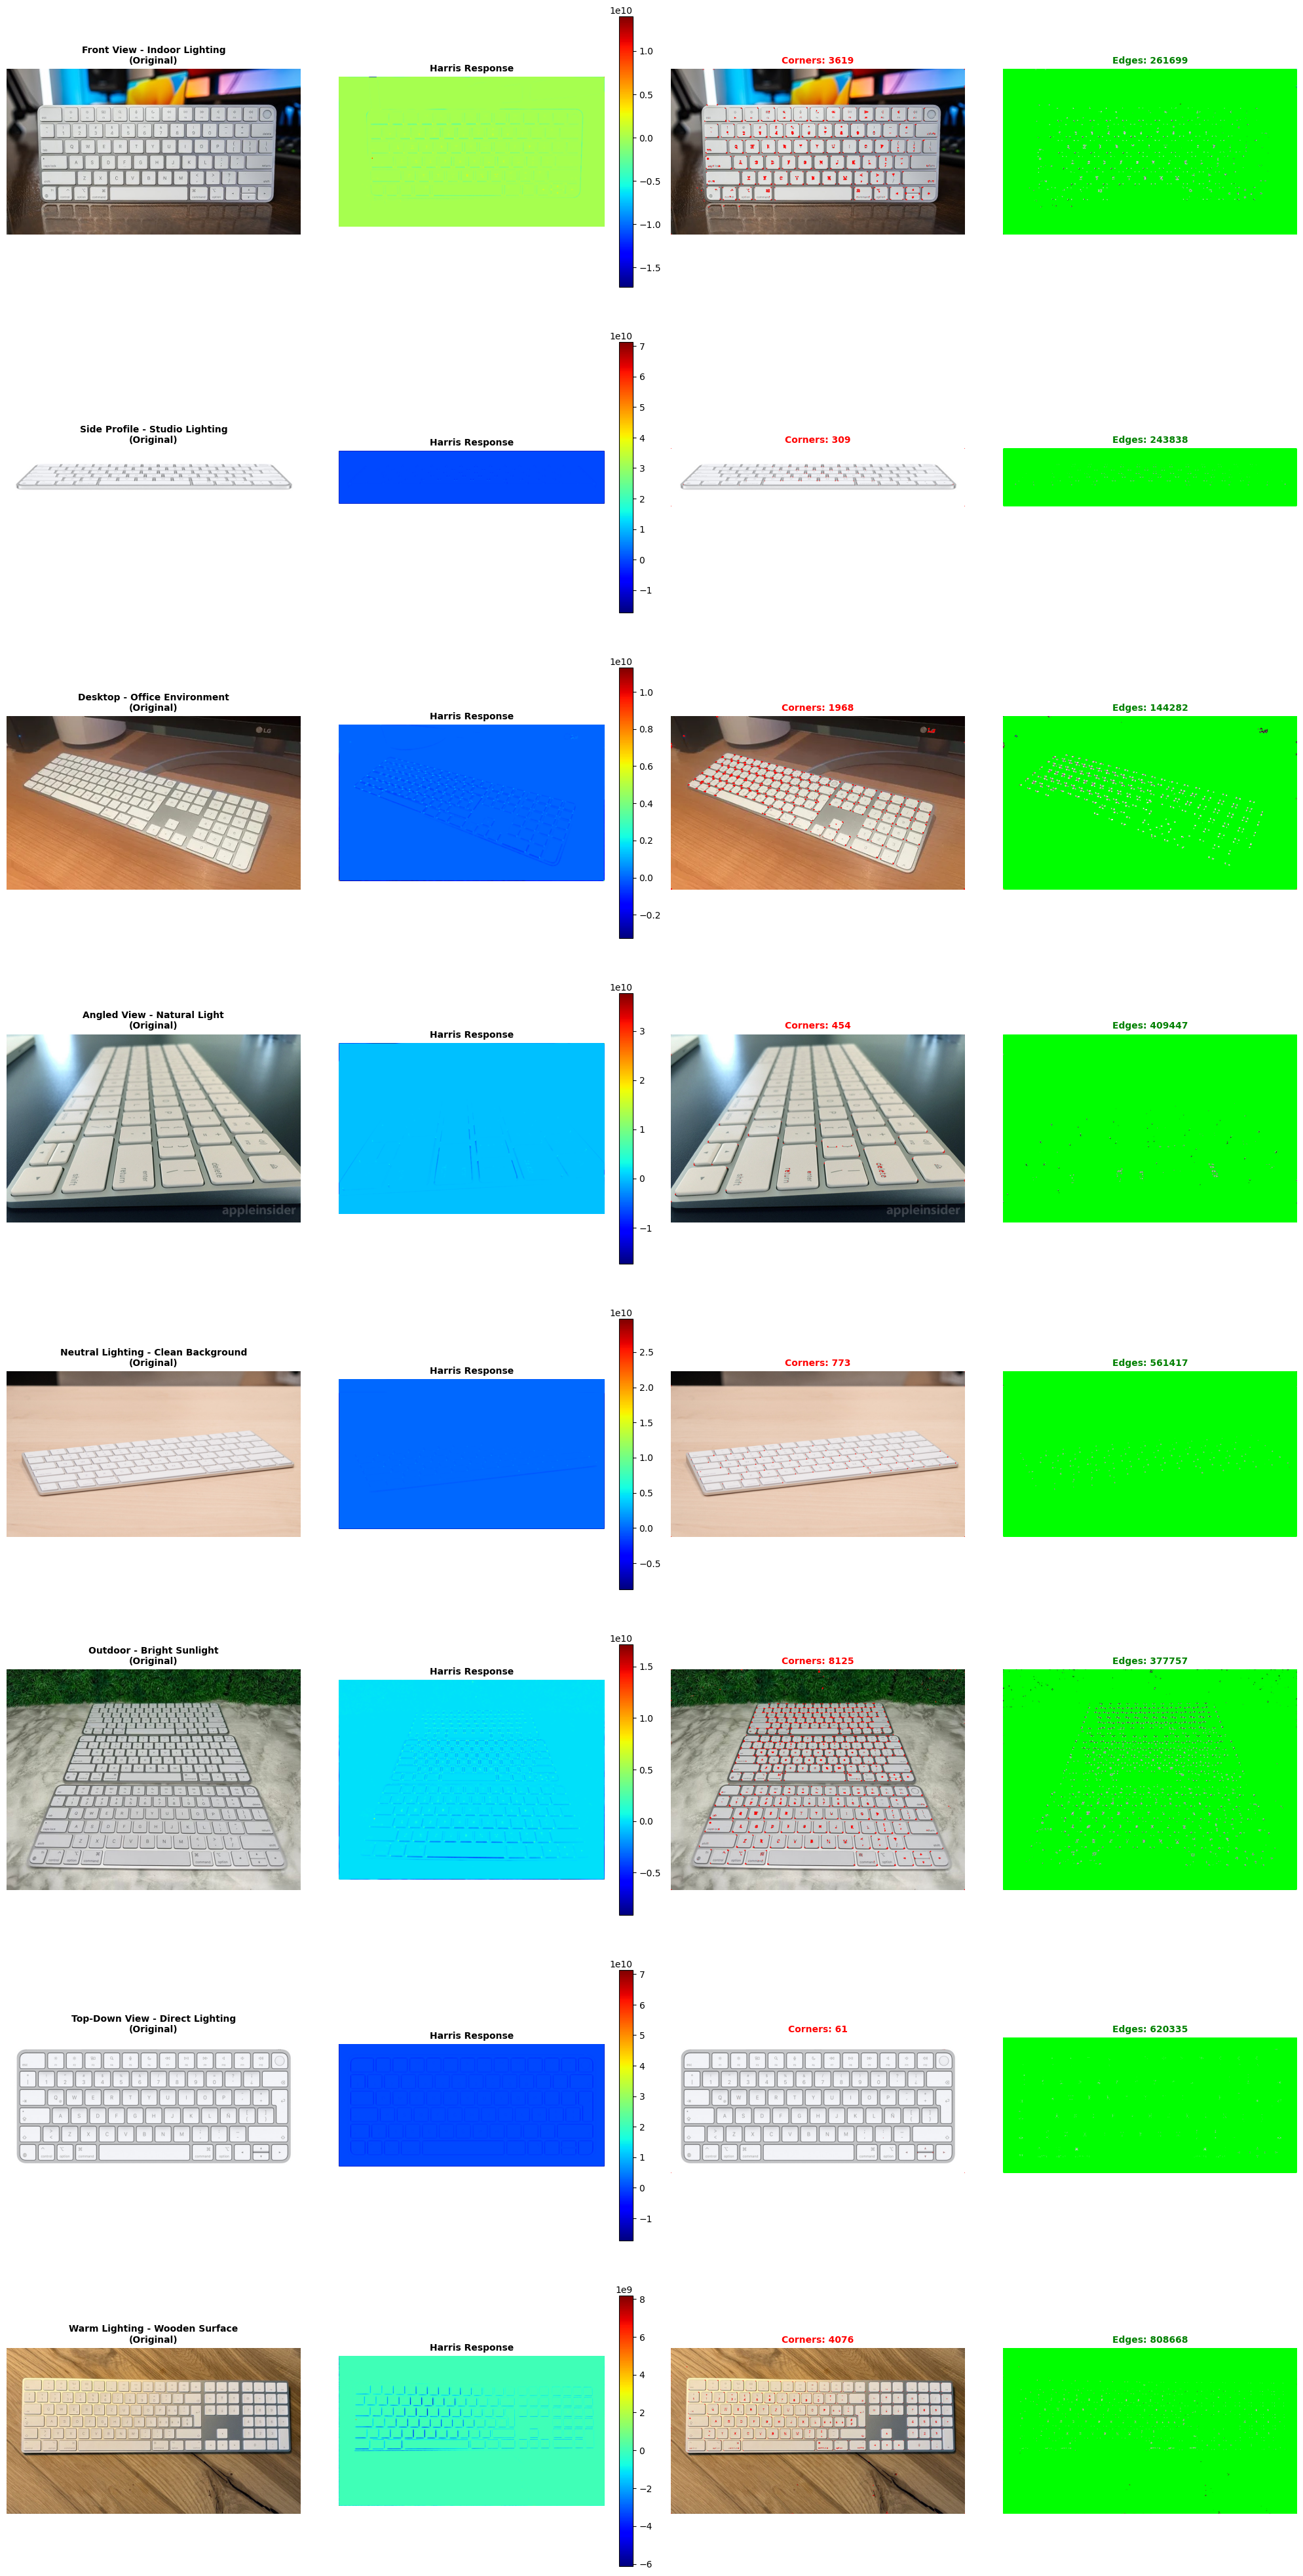

In [16]:
# Create comprehensive visualization
fig, axes = plt.subplots(len(results), 4, figsize=(20, 5*len(results)))

if len(results) == 1:
    axes = axes.reshape(1, -1)

for idx, result in enumerate(results):
    # Original image
    axes[idx, 0].imshow(result['original'])
    axes[idx, 0].set_title(f"{result['label']}\n(Original)", fontsize=10, fontweight='bold')
    axes[idx, 0].axis('off')
    
    # Harris response heatmap
    im = axes[idx, 1].imshow(result['response'], cmap='jet')
    axes[idx, 1].set_title('Harris Response', fontsize=10, fontweight='bold')
    axes[idx, 1].axis('off')
    plt.colorbar(im, ax=axes[idx, 1], fraction=0.046)
    
    # Detected corners
    axes[idx, 2].imshow(result['corners_img'])
    axes[idx, 2].set_title(f"Corners: {result['num_corners']}", fontsize=10, fontweight='bold', color='red')
    axes[idx, 2].axis('off')
    
    # Detected edges
    axes[idx, 3].imshow(result['edges_img'])
    axes[idx, 3].set_title(f"Edges: {result['num_edges']}", fontsize=10, fontweight='bold', color='green')
    axes[idx, 3].axis('off')

plt.tight_layout()
plt.show()

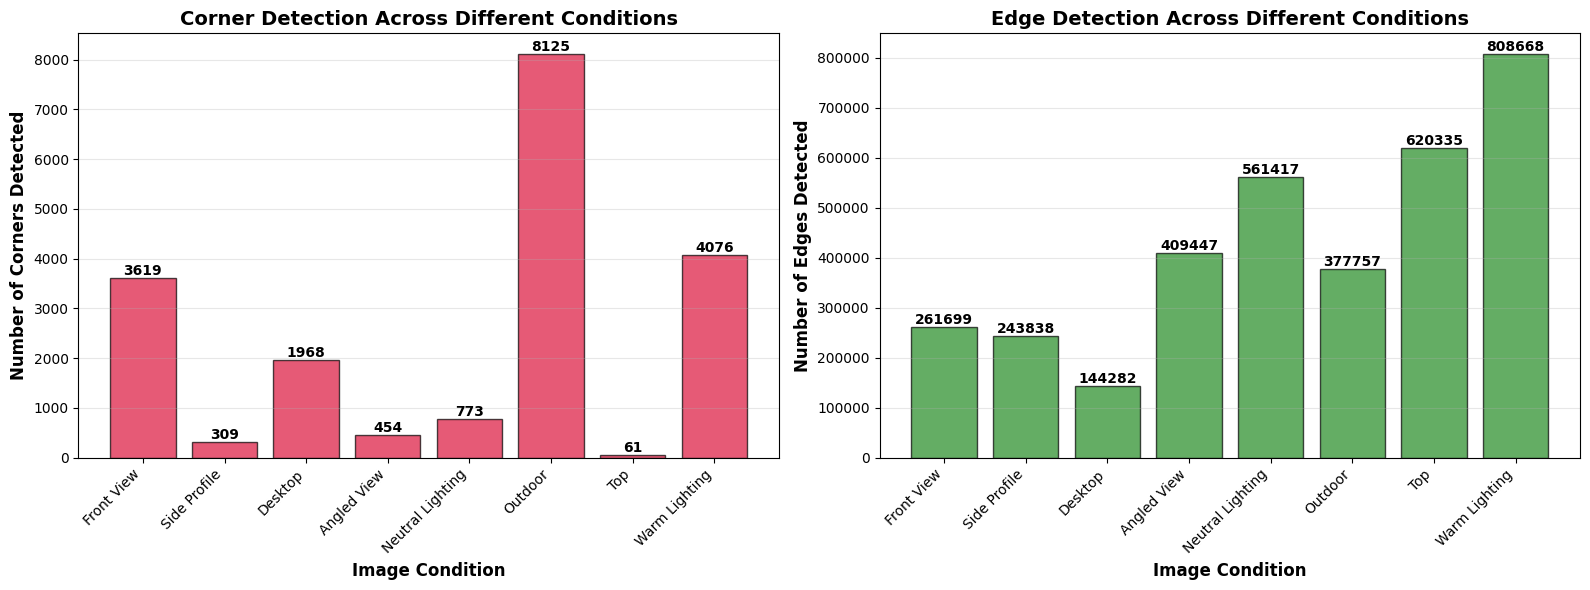

In [17]:
# Extract feature counts for comparison
labels_short = [r['label'].split('-')[0].strip() for r in results]
corner_counts = [r['num_corners'] for r in results]
edge_counts = [r['num_edges'] for r in results]

# Create comparison bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

x_pos = np.arange(len(labels_short))

# Corners comparison
bars1 = ax1.bar(x_pos, corner_counts, color='crimson', alpha=0.7, edgecolor='black')
ax1.set_xlabel('Image Condition', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Corners Detected', fontsize=12, fontweight='bold')
ax1.set_title('Corner Detection Across Different Conditions', fontsize=14, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(labels_short, rotation=45, ha='right')
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontweight='bold')

# Edges comparison
bars2 = ax2.bar(x_pos, edge_counts, color='forestgreen', alpha=0.7, edgecolor='black')
ax2.set_xlabel('Image Condition', fontsize=12, fontweight='bold')
ax2.set_ylabel('Number of Edges Detected', fontsize=12, fontweight='bold')
ax2.set_title('Edge Detection Across Different Conditions', fontsize=14, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(labels_short, rotation=45, ha='right')
ax2.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

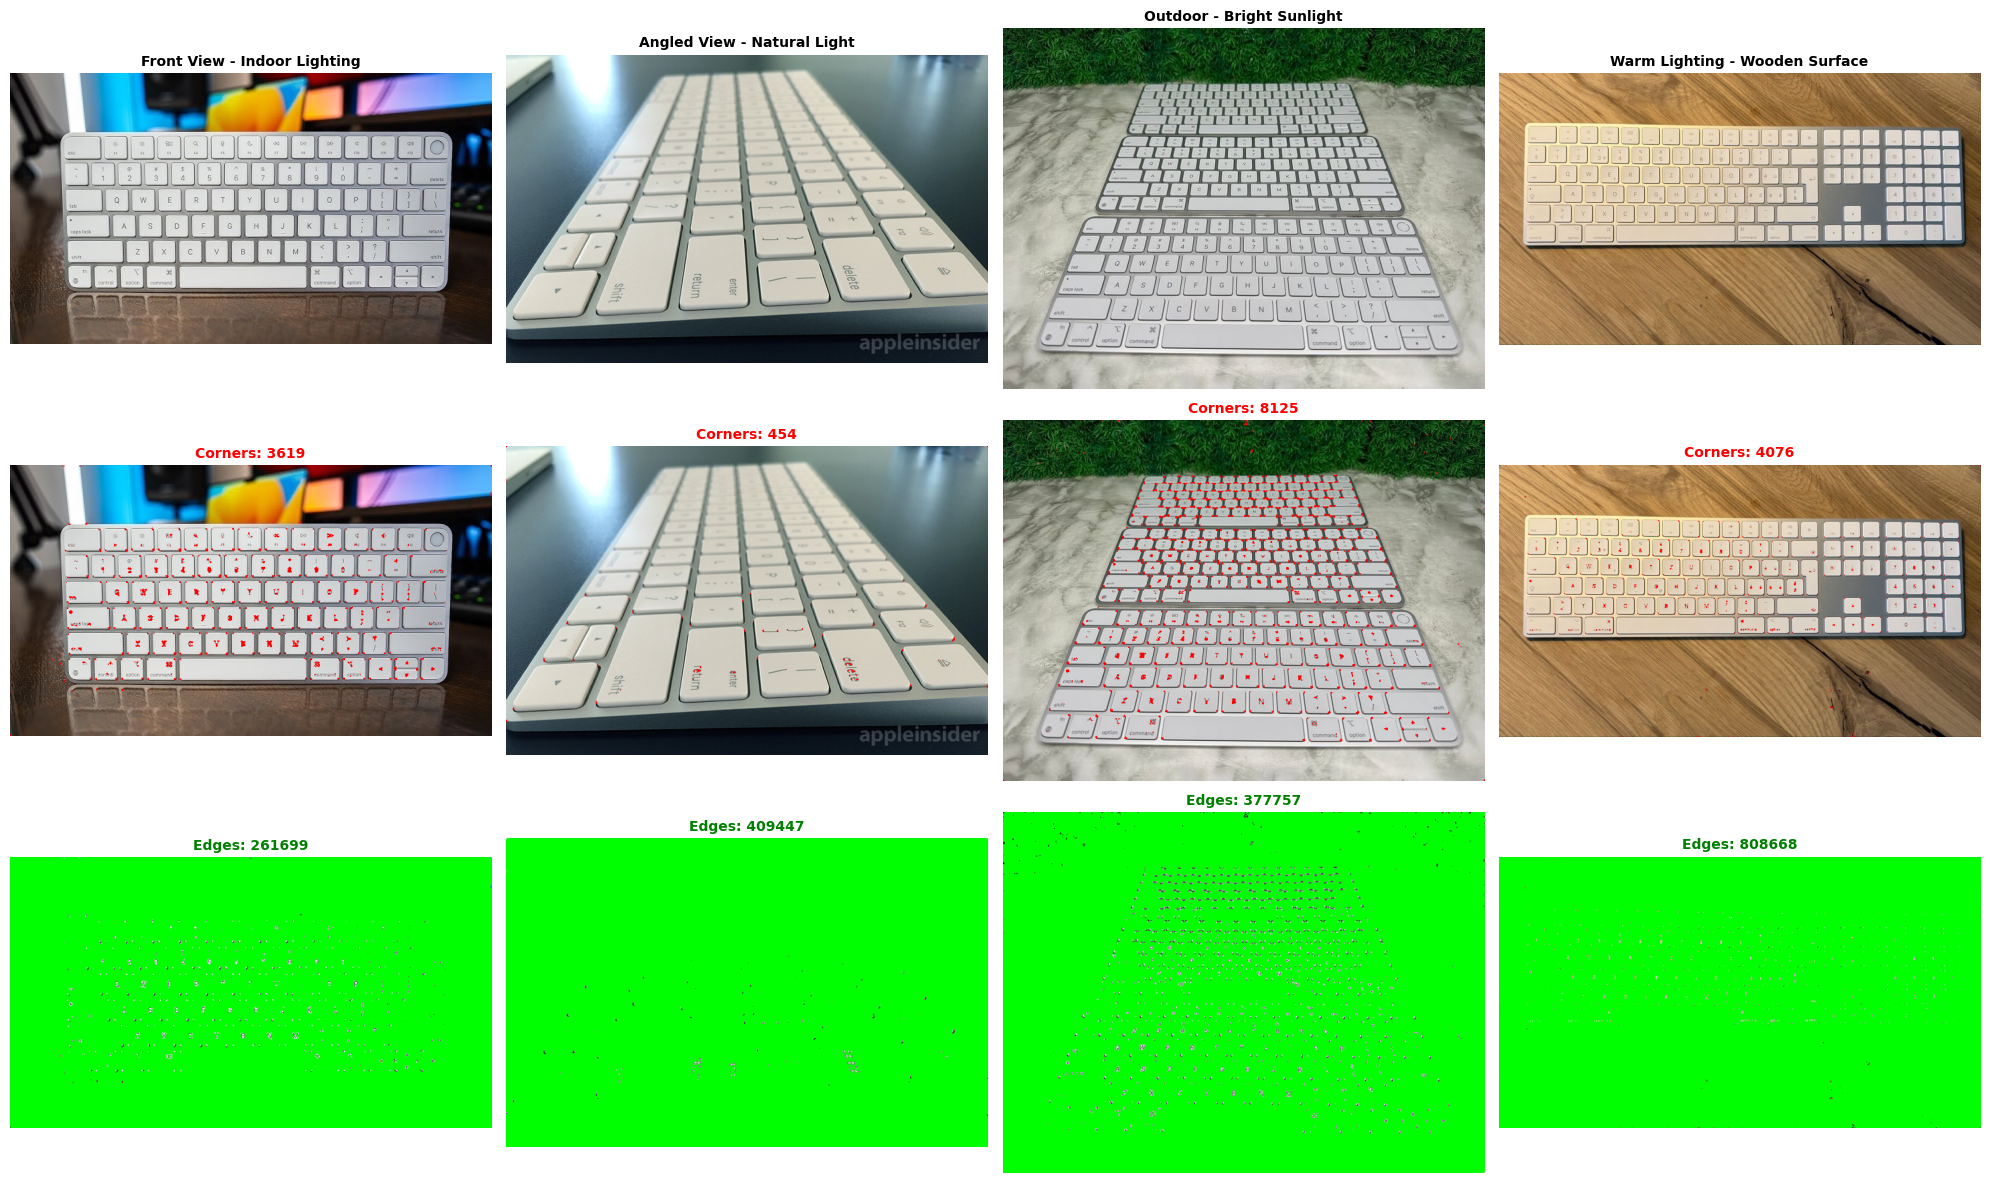

In [18]:
# Select specific conditions for detailed comparison
comparison_indices = [0, 3, 5, 7]  # Front, Angled, Outdoor, Warm lighting

fig, axes = plt.subplots(3, len(comparison_indices), figsize=(20, 12))

for col_idx, img_idx in enumerate(comparison_indices):
    result = results[img_idx]
    
    # Original
    axes[0, col_idx].imshow(result['original'])
    axes[0, col_idx].set_title(result['label'], fontsize=10, fontweight='bold')
    axes[0, col_idx].axis('off')
    
    # Corners
    axes[1, col_idx].imshow(result['corners_img'])
    axes[1, col_idx].set_title(f"Corners: {result['num_corners']}", 
                                fontsize=10, fontweight='bold', color='red')
    axes[1, col_idx].axis('off')
    
    # Edges
    axes[2, col_idx].imshow(result['edges_img'])
    axes[2, col_idx].set_title(f"Edges: {result['num_edges']}", 
                                fontsize=10, fontweight='bold', color='green')
    axes[2, col_idx].axis('off')

# Add row labels
axes[0, 0].set_ylabel('Original', fontsize=12, fontweight='bold', rotation=0, labelpad=60)
axes[1, 0].set_ylabel('Corners', fontsize=12, fontweight='bold', rotation=0, labelpad=60)
axes[2, 0].set_ylabel('Edges', fontsize=12, fontweight='bold', rotation=0, labelpad=60)

plt.tight_layout()
plt.show()

The experimental results reveal significant variations in the Harris detector's performance across different lighting conditions and viewing angles. As illustrated in the comparative bar charts, corner detection exhibited considerable sensitivity to environmental factors, with counts ranging from a minimum of 61 corners in the top-down view to a maximum of 8,125 corners in the outdoor bright sunlight condition. This dramatic variation (spanning more than two orders of magnitude) demonstrates that illumination intensity and angle play critical roles in the detector's ability to identify corner features. The outdoor sunlight condition produced the highest corner count, likely due to enhanced contrast and sharply defined shadows that amplify gradient magnitudes at key boundaries. Conversely, the top-down view with direct overhead lighting resulted in minimal corner detection, suggesting that this configuration produces relatively uniform illumination that reduces the intensity variations necessary for corner identification. The indoor lighting conditions (front view, desktop, and warm lighting) yielded moderate corner counts ranging from 1,968 to 4,076, indicating stable but less pronounced feature detection under controlled artificial illumination.

Edge detection patterns exhibited different but equally informative trends across the test conditions. The warm lighting configuration on a wooden surface generated the highest edge count at 808,668 detected edges, followed closely by the top-down view (620,335 edges) and neutral lighting condition (561,417 edges). These elevated edge counts can be attributed to texture-rich backgrounds and subtle variations in surface reflectance that create numerous low-magnitude gradient transitions throughout the image. In contrast, the desktop office environment produced the lowest edge detection at 144,282 edges, likely due to a cleaner background and more uniform surface characteristics that minimize spurious edge responses. The outdoor bright sunlight condition, despite producing the highest corner count, yielded a moderate edge count of 377,757, suggesting that strong directional lighting creates distinct corners while simultaneously reducing the detection of subtle edge features through high-contrast shadowing effects. This inverse relationship between corner and edge detection under certain conditions highlights the complementary nature of these features and the importance of selecting appropriate detection thresholds for specific applications.

The Harris response heatmaps provide valuable insight into the spatial distribution of feature strength across different conditions. In the outdoor sunlight and front view conditions, the response maps exhibit concentrated regions of high positive values (red/yellow in the heatmap) corresponding to the keyboard's corners and key edges, while maintaining relatively low background noise. This pattern indicates robust feature localization with clear distinction between signal and noise. Conversely, conditions such as the side profile and top-down views show more uniform response distributions with predominantly blue regions, suggesting that the geometric perspective and lighting angle failed to generate sufficient gradient diversity for strong corner responses. The detailed side-by-side comparison further emphasizes that viewpoint angle may be as influential as lighting conditions: the angled view under natural light detected only 454 corners despite reasonable illumination, while the front view with indoor lighting captured 3,619 corners. These findings confirm that the Harris detector performs optimally when the camera axis is approximately perpendicular to feature-rich surfaces with moderate to high contrast lighting, and its performance degrades substantially under extreme angles or overly uniform illumination that diminishes the local gradient structure upon which the algorithm fundamentally relies.